#  Module 1: Language Detection
### Multi-Class Text Classifier using Traditional NLP + Machine Learning

---

**Objective:** Build a robust language detection classifier that:
- Uses **TF-IDF** (character n-grams) as the core feature extractor
- Trains and benchmarks multiple ML models
- Selects the **best model** based on cross-validated accuracy
- Exposes a clean `detect_language(text)` inference API for downstream modules

**Supported Languages (expandable):** Arabic, English, French, German, Spanish, Italian, Portuguese, Dutch, Russian, Chinese, Japanese, Korean, Turkish, Swedish, Polish

---

##  1. Install & Import Dependencies

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn langdetect datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
import joblib
import os

warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


##  2. Dataset Preparation

We use **two complementary sources** then combine them:
1. `papluca/language-identification` from HuggingFace — 90k samples, 20 languages



In [ ]:
#   Load from HuggingFace
try:
    from datasets import load_dataset
    print("Loading papluca/language-identification dataset...")
    hf_dataset = load_dataset("papluca/language-identification")

    train_hf = hf_dataset['train'].to_pandas().rename(columns={'labels': 'language'})
    val_hf   = hf_dataset['validation'].to_pandas().rename(columns={'labels': 'language'})
    test_hf  = hf_dataset['test'].to_pandas().rename(columns={'labels': 'language'})

    raw_df = pd.concat([train_hf, val_hf, test_hf], ignore_index=True)[['text', 'language']]
    print(f"✅ Loaded {len(raw_df):,} samples | Languages: {raw_df['language'].nunique()}")
    USE_HF = True

except Exception as e:
    print(f"⚠️  HuggingFace load failed ({e}). Falling back to built-in demo set...")
    USE_HF = False

Loading papluca/language-identification dataset...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Loaded 90,000 samples | Languages: 20


In [ ]:
#  Dataset Overview
print("=" * 55)
print(f"{'DATASET SUMMARY':^55}")
print("=" * 55)
print(f"Total samples  : {len(raw_df):,}")
print(f"Languages      : {raw_df['language'].nunique()}")
print(f"Missing text   : {raw_df['text'].isna().sum()}")
print("\nClass distribution:")
print(raw_df['language'].value_counts().to_string())
raw_df.head(5)

                    DATASET SUMMARY                    
Total samples  : 90,000
Languages      : 20
Missing text   : 0

Class distribution:
language
pt    4500
bg    4500
zh    4500
th    4500
ru    4500
pl    4500
ur    4500
sw    4500
tr    4500
es    4500
ar    4500
it    4500
hi    4500
de    4500
el    4500
nl    4500
fr    4500
vi    4500
en    4500
ja    4500


,text,language
0,"os chefes de defesa da estónia, letónia, lituâ...",pt
1,размерът на хоризонталната мрежа може да бъде ...,bg
2,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,zh
3,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,th
4,Он увеличил давление .,ru


##  3. Exploratory Data Analysis (EDA)

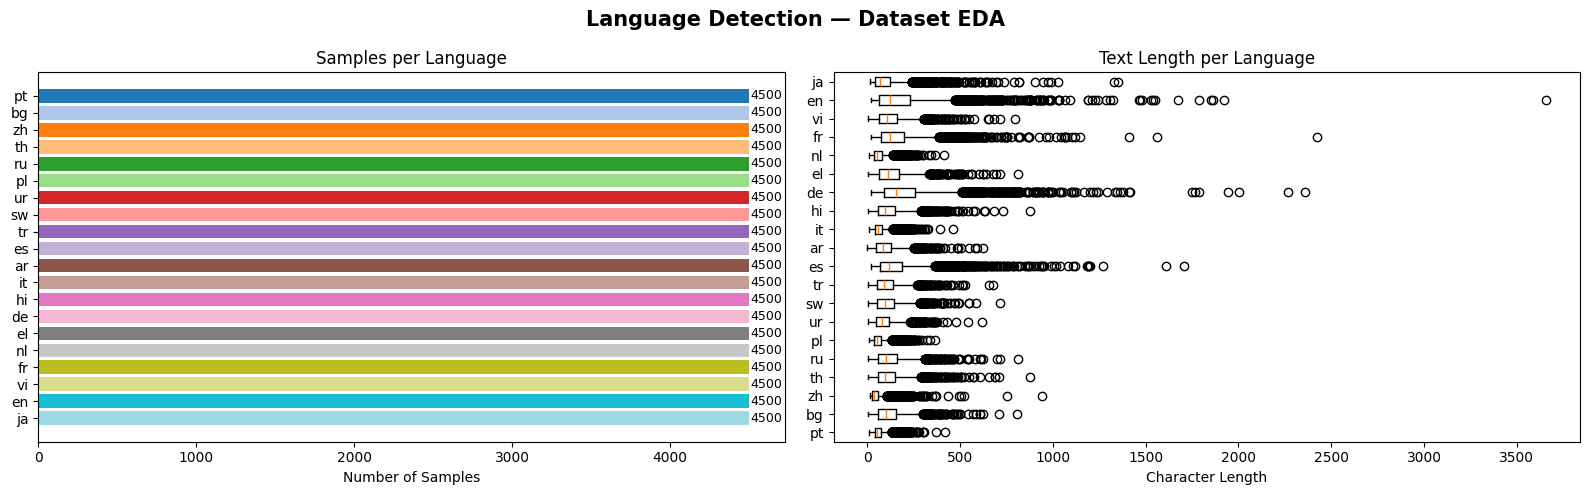


Median text length: 83 chars
Max text length:    3657 chars


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Language Detection — Dataset EDA', fontsize=15, fontweight='bold')
# Class distribution
lang_counts = raw_df['language'].value_counts()
axes[0].barh(lang_counts.index, lang_counts.values, color=plt.cm.tab20.colors[:len(lang_counts)])
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Samples per Language')
axes[0].invert_yaxis()
for i, v in enumerate(lang_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

raw_df['text_len'] = raw_df['text'].str.len()
axes[1].boxplot(
    [raw_df[raw_df['language'] == lang]['text_len'].values for lang in lang_counts.index],
    labels=lang_counts.index, vert=False
)
axes[1].set_xlabel('Character Length')
axes[1].set_title('Text Length per Language')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMedian text length: {raw_df['text_len'].median():.0f} chars")
print(f"Max text length:    {raw_df['text_len'].max()} chars")

##  4. Preprocessing & Feature Engineering

### Why Character N-Grams?
- Language identity lives in **character patterns** (morphemes, script, diacritics), not word semantics.
- Character n-grams are **script-agnostic** — they work natively on Arabic, Chinese, Cyrillic, etc.
- They are **robust to spelling variants** and short texts (tweet-length).


In [ ]:
def preprocess_text(text: str) -> str:
    """
    Lightweight preprocessing — we intentionally keep diacritics and script
    characters because they are discriminative for language detection.
    """
    if not isinstance(text, str):
        return ""
    text = ' '.join(text.strip().split())
    return text
# Apply preprocessing
raw_df['text_clean'] = raw_df['text'].apply(preprocess_text)
raw_df = raw_df[raw_df['text_clean'].str.len() > 3].reset_index(drop=True)

print(f"Samples after cleaning: {len(raw_df):,}")
# Encode labels
le = LabelEncoder()
raw_df['label'] = le.fit_transform(raw_df['language'])
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Samples after cleaning: 89,994
Label mapping: {'ar': np.int64(0), 'bg': np.int64(1), 'de': np.int64(2), 'el': np.int64(3), 'en': np.int64(4), 'es': np.int64(5), 'fr': np.int64(6), 'hi': np.int64(7), 'it': np.int64(8), 'ja': np.int64(9), 'nl': np.int64(10), 'pl': np.int64(11), 'pt': np.int64(12), 'ru': np.int64(13), 'sw': np.int64(14), 'th': np.int64(15), 'tr': np.int64(16), 'ur': np.int64(17), 'vi': np.int64(18), 'zh': np.int64(19)}


In [ ]:
# ── Train / Test Split (stratified) ──────────────────────────────────────────
X = raw_df['text_clean']
y = raw_df['language']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nClass balance in train:\n{y_train.value_counts()}")

Train size : 71,995
Test size  : 17,999

Class balance in train:
language
pt    3600
ru    3600
zh    3600
pl    3600
bg    3600
es    3600
nl    3600
it    3600
hi    3600
th    3600
sw    3600
en    3600
de    3600
fr    3600
el    3600
vi    3600
ja    3600
tr    3599
ar    3599
ur    3597
Name: count, dtype: int64


##  5. Model Training & Benchmarking

We build **sklearn Pipelines** (vectorizer → classifier) for 6 models and compare them fairly using 5-fold stratified cross-validation on the training set.

In [ ]:
#  Vectorizer Configuration
# Best practice: TF-IDF + character (2,4)-grams
TFIDF_CHAR = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=150_000,
    sublinear_tf=True,
    strip_accents=None,
    min_df=2,
)

# Alternate: Count-based for NaiveBayes
COUNT_CHAR = CountVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=150_000,
    min_df=2,
)

print("✅ Vectorizers configured")

✅ Vectorizers configured


In [ ]:
#  Define Candidate Models

MODELS = {
    "Multinomial NaiveBayes": Pipeline([
        ('vec', COUNT_CHAR),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    "Complement NaiveBayes": Pipeline([
        ('vec', COUNT_CHAR),
        ('clf', ComplementNB(alpha=0.1))
    ]),
    "Logistic Regression": Pipeline([
        ('vec', TFIDF_CHAR),
        ('clf', LogisticRegression(
            C=5.0,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            n_jobs=-1,
            random_state=42
        ))
    ]),
    "Linear SVM": Pipeline([
        ('vec', TFIDF_CHAR),
        ('clf', CalibratedClassifierCV(LinearSVC(
            C=1.0,
            max_iter=2000,
            random_state=42
        ), cv=3))
    ]),
    "SGD Classifier": Pipeline([
        ('vec', TFIDF_CHAR),
        ('clf', SGDClassifier(
            loss='modified_huber',
            alpha=1e-4,
            max_iter=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Random Forest": Pipeline([
        ('vec', TFIDF_CHAR),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            n_jobs=-1,
            random_state=42
        ))
    ]),
}

print(f"✅ {len(MODELS)} candidate models defined")

✅ 6 candidate models defined


In [ ]:
#  Cross-Validation Benchmark

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print(f"{'Model':<28} {'CV Acc Mean':>12} {'CV Acc Std':>11} {'Train Time':>11}")
print("-" * 66)

for name, pipeline in MODELS.items():
    t0 = time.time()
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=CV, scoring='accuracy', n_jobs=-1
    )
    elapsed = time.time() - t0
    results.append({
        'Model': name,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Train_Time': elapsed
    })
    print(f"{name:<28} {cv_scores.mean():>12.4f} ± {cv_scores.std():>8.4f}   {elapsed:>8.2f}s")

results_df = pd.DataFrame(results).sort_values('CV_Mean', ascending=False).reset_index(drop=True)
print("\n🏆 Ranking:")
print(results_df[['Model','CV_Mean','CV_Std','Train_Time']].to_string(index=False))

Model                         CV Acc Mean  CV Acc Std  Train Time
------------------------------------------------------------------
Multinomial NaiveBayes             0.9967 ±   0.0003     122.10s
Complement NaiveBayes              0.9901 ±   0.0005     112.98s
Logistic Regression                0.9967 ±   0.0002     840.88s
Linear SVM                         0.9972 ±   0.0003     246.60s
SGD Classifier                     0.9969 ±   0.0002     150.54s
Random Forest                      0.9917 ±   0.0005    2784.46s

🏆 Ranking:
                 Model  CV_Mean   CV_Std  Train_Time
            Linear SVM 0.997208 0.000315  246.595265
        SGD Classifier 0.996944 0.000248  150.536883
Multinomial NaiveBayes 0.996722 0.000344  122.095900
   Logistic Regression 0.996653 0.000242  840.880187
         Random Forest 0.991736 0.000525 2784.457033
 Complement NaiveBayes 0.990083 0.000519  112.982723


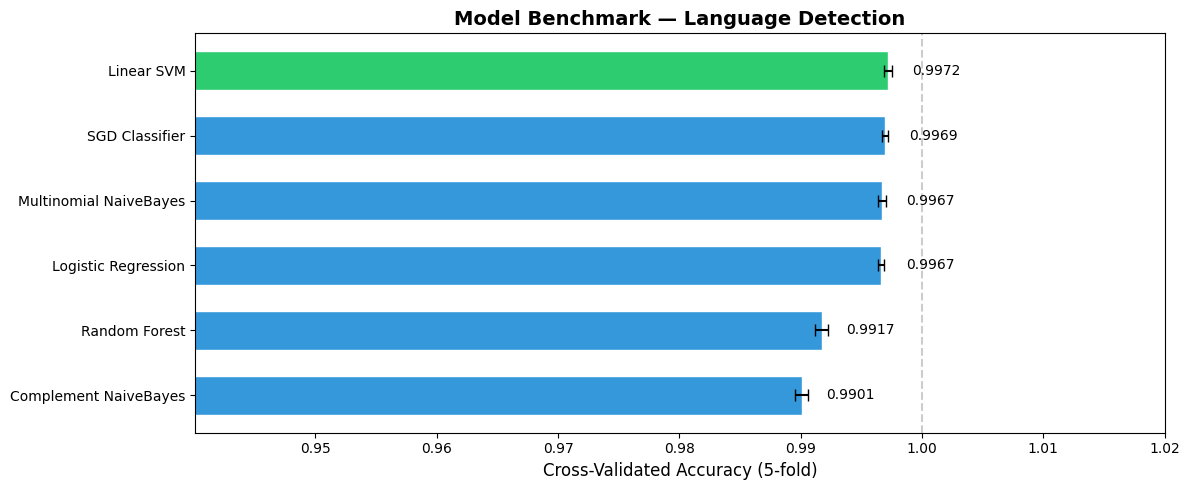

In [ ]:
#  Visualise Benchmark Results
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = ax.barh(
    results_df['Model'][::-1],
    results_df['CV_Mean'][::-1],
    xerr=results_df['CV_Std'][::-1],
    color=colors[::-1],
    edgecolor='white',
    capsize=4,
    height=0.6
)
ax.set_xlabel('Cross-Validated Accuracy (5-fold)', fontsize=12)
ax.set_title('Model Benchmark — Language Detection', fontsize=14, fontweight='bold')
ax.set_xlim(results_df['CV_Mean'].min() - 0.05, 1.02)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.4)

for bar, val in zip(bars, results_df['CV_Mean'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

##  6. Best Model — Full Training & Evaluation

In [ ]:
#  Select Best Model
best_name = results_df.iloc[0]['Model']
best_pipeline = MODELS[best_name]

print(f"🏆Best Model Selected: {best_name}")
print(f"   CV Accuracy: {results_df.iloc[0]['CV_Mean']:.4f} ± {results_df.iloc[0]['CV_Std']:.4f}")
print("\nTraining on full training set...")

t0 = time.time()
best_pipeline.fit(X_train, y_train)
print(f"✅Training complete in {time.time() - t0:.2f}s")

🏆 Best Model Selected: Linear SVM
   CV Accuracy: 0.9972 ± 0.0003

Training on full training set...
✅ Training complete in 71.40s


In [ ]:
#  Test Set Evaluation
y_pred = best_pipeline.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average='weighted')

print("=" * 55)
print(f"{'TEST SET RESULTS':^55}")
print("=" * 55)
print(f"Model        : {best_name}")
print(f"Accuracy     : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Weighted F1  : {test_f1:.4f}")
print("=" * 55)

print("\n--- Per-Language Classification Report ---")
print(classification_report(y_test, y_pred))

                   TEST SET RESULTS                    
Model        : Linear SVM
Accuracy     : 0.9974 (99.74%)
Weighted F1  : 0.9974

--- Per-Language Classification Report ---
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       900
          bg       0.99      0.99      0.99       900
          de       1.00      1.00      1.00       900
          el       1.00      1.00      1.00       900
          en       0.99      1.00      1.00       900
          es       1.00      1.00      1.00       900
          fr       1.00      1.00      1.00       900
          hi       1.00      1.00      1.00       900
          it       1.00      1.00      1.00       900
          ja       1.00      1.00      1.00       900
          nl       0.99      1.00      1.00       900
          pl       1.00      0.99      1.00       900
          pt       1.00      0.99      0.99       900
          ru       0.99      0.99      0.99       900
          

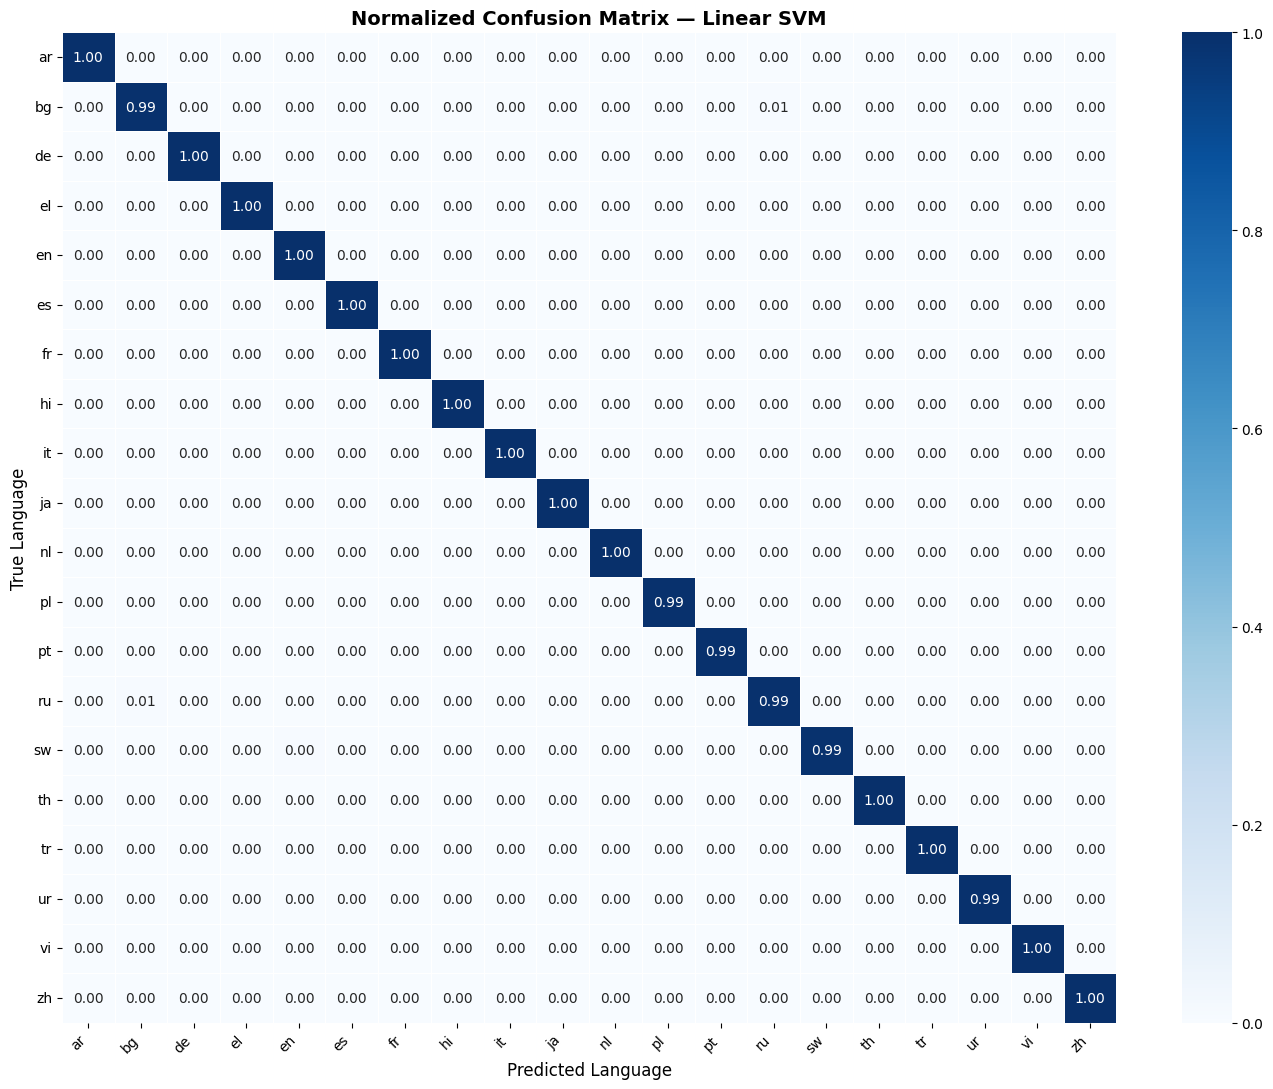


Diagonal = correct predictions per language


In [ ]:
#  Confusion Matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor='white',
    ax=ax, vmin=0, vmax=1
)
ax.set_xlabel('Predicted Language', fontsize=12)
ax.set_ylabel('True Language', fontsize=12)
ax.set_title(f'Normalized Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDiagonal = correct predictions per language")

##  7. Error Analysis

In [ ]:
#  Analyse Misclassifications
errors_df = pd.DataFrame({
    'text': X_test.values,
    'true_lang': y_test.values,
    'pred_lang': y_pred
})
errors_df = errors_df[errors_df['true_lang'] != errors_df['pred_lang']]
print(f"Total misclassifications: {len(errors_df)} / {len(X_test)} ({len(errors_df)/len(X_test)*100:.2f}%)")

if len(errors_df) > 0:
    print("\nTop confusion pairs:")
    confusion_pairs = errors_df.groupby(['true_lang', 'pred_lang']).size().sort_values(ascending=False).head(10)
    print(confusion_pairs.to_string())

    print("\n--- Sample Misclassifications ---")
    for _, row in errors_df.head(8).iterrows():
        print(f"  TEXT    : {row['text'][:70]}")
        print(f"  TRUE    : {row['true_lang']}  →  PRED: {row['pred_lang']}")
        print()

Total misclassifications: 46 / 17999 (0.26%)

Top confusion pairs:
true_lang  pred_lang
bg         ru           6
ru         bg           5
sw         en           4
ur         en           3
pt         nl           3
es         pt           2
it         pt           2
pt         pl           2
pl         nl           2
           it           2

--- Sample Misclassifications ---
  TEXT    : and and the next yeah point seven five liters and then liters and then
  TRUE    : ur  →  PRED: en

  TEXT    : ... nach 2 Tagen Interesse verloren...
  TRUE    : de  →  PRED: nl

  TEXT    : UK Leader Signals Support for Airstrikes on IS na Síria
  TRUE    : pt  →  PRED: pl

  TEXT    : NEA survey ka aik hi sawal hah Kya tum ne koi adab parha hai guzishta 
  TRUE    : ur  →  PRED: sw

  TEXT    : не алф !
  TRUE    : bg  →  PRED: ru

  TEXT    : Pathogen hazard analysis ( haccp )
  TRUE    : sw  →  PRED: ur

  TEXT    : aadhunik mahilaen Romantic shira mein maheen hona pasand karti hai, ma
  TRUE 

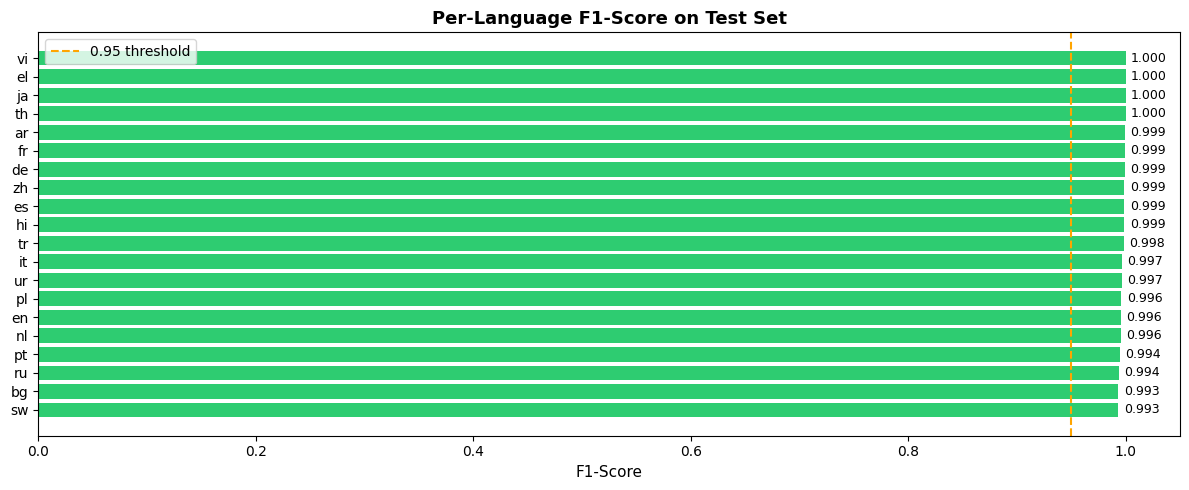

In [ ]:
#  Per-language F1 bar chart
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, output_dict=True)
lang_f1 = {k: v['f1-score'] for k, v in report.items() if k not in ['accuracy','macro avg','weighted avg']}
lang_f1_df = pd.DataFrame(list(lang_f1.items()), columns=['language','f1']).sort_values('f1')

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#e74c3c' if f < 0.95 else '#2ecc71' for f in lang_f1_df['f1']]
ax.barh(lang_f1_df['language'], lang_f1_df['f1'], color=bar_colors)
ax.axvline(0.95, color='orange', linestyle='--', label='0.95 threshold')
ax.set_xlabel('F1-Score', fontsize=11)
ax.set_title('Per-Language F1-Score on Test Set', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend()
for i, (_, row) in enumerate(lang_f1_df.iterrows()):
    ax.text(row['f1'] + 0.005, i, f"{row['f1']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('per_language_f1.png', dpi=150, bbox_inches='tight')
plt.show()

##  8. Confidence Analysis

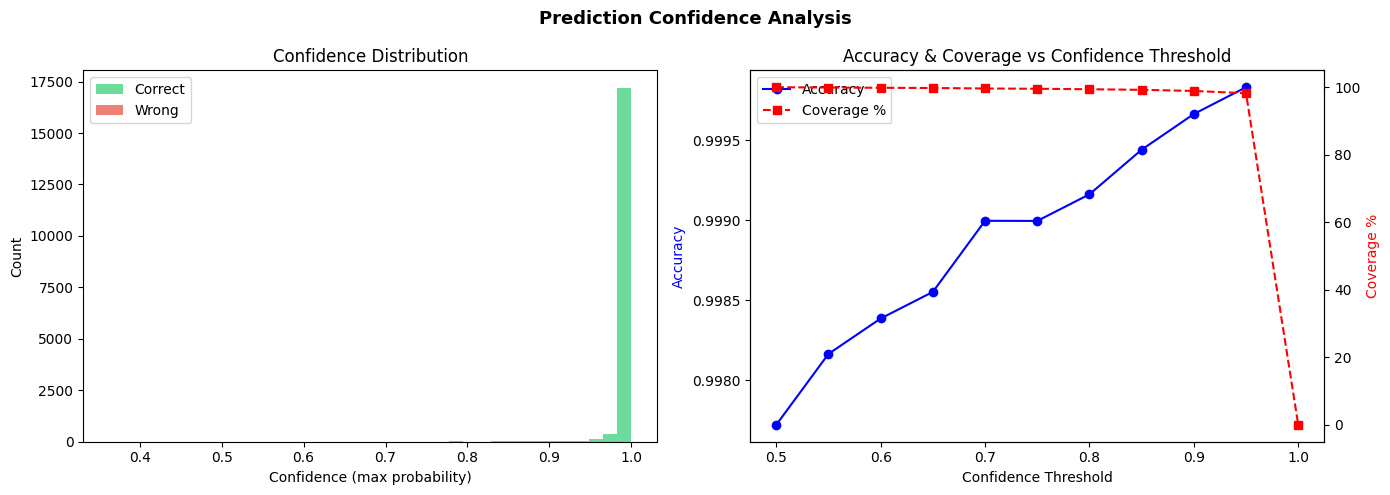

Mean confidence on correct predictions : 0.9928
Mean confidence on wrong  predictions : 0.6846


In [ ]:
#  Prediction Confidence Distribution
try:
    proba = best_pipeline.predict_proba(X_test)
    top_conf = proba.max(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Prediction Confidence Analysis', fontsize=13, fontweight='bold')

    correct = y_pred == y_test.values
    axes[0].hist(top_conf[correct], bins=30, alpha=0.7, label='Correct', color='#2ecc71')
    axes[0].hist(top_conf[~correct], bins=30, alpha=0.7, label='Wrong', color='#e74c3c')
    axes[0].set_xlabel('Confidence (max probability)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Confidence Distribution')
    axes[0].legend()

    thresholds = np.arange(0.5, 1.01, 0.05)
    acc_at_thresh, coverage = [], []
    for t in thresholds:
        mask = top_conf >= t
        if mask.sum() > 0:
            acc_at_thresh.append(accuracy_score(y_test.values[mask], y_pred[mask]))
            coverage.append(mask.mean() * 100)
        else:
            acc_at_thresh.append(np.nan)
            coverage.append(0)

    ax2 = axes[1]
    line1 = ax2.plot(thresholds, acc_at_thresh, 'b-o', label='Accuracy')
    ax2.set_xlabel('Confidence Threshold')
    ax2.set_ylabel('Accuracy', color='b')
    ax2.set_title('Accuracy & Coverage vs Confidence Threshold')
    ax3 = ax2.twinx()
    line2 = ax3.plot(thresholds, coverage, 'r--s', label='Coverage %')
    ax3.set_ylabel('Coverage %', color='r')
    lines = line1 + line2
    ax2.legend(lines, [l.get_label() for l in lines])

    plt.tight_layout()
    plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Mean confidence on correct predictions : {top_conf[correct].mean():.4f}")
    print(f"Mean confidence on wrong  predictions : {top_conf[~correct].mean():.4f}")
    HAS_PROBA = True
except Exception:
    print("⚠️  Model does not support predict_proba. Skipping confidence analysis.")
    HAS_PROBA = False

##  9. Save Model & Build Inference API

In [ ]:
#  Persist Model + Label Encoder
os.makedirs('models', exist_ok=True)
MODEL_PATH = 'models/language_detector.joblib'
META_PATH  = 'models/language_detector_meta.joblib'
joblib.dump(best_pipeline, MODEL_PATH, compress=3)
joblib.dump({
    'classes': list(best_pipeline.classes_) if hasattr(best_pipeline, 'classes_') else list(y_train.unique()),
    'model_name': best_name,
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'languages': sorted(y.unique().tolist())
}, META_PATH)
print(f"✅ Model saved  → {MODEL_PATH}")
print(f"✅ Metadata saved → {META_PATH}")
print(f"   Model size: {os.path.getsize(MODEL_PATH) / 1e6:.1f} MB")

✅ Model saved  → models/language_detector.joblib
✅ Metadata saved → models/language_detector_meta.joblib
   Model size: 32.2 MB


##  10. Live Demo

In [ ]:
#  Single-text detection
TEST_SENTENCES = [
    ("مرحباً كيف حالك اليوم؟ أنا بخير شكراً",                     "ar"),
    ("Hello! How are you doing today? I hope you're well.",           "en"),
    ("Bonjour! Comment allez-vous aujourd'hui?",                      "fr"),
    ("Guten Tag! Wie geht es Ihnen heute?",                           "de"),
    ("¡Hola! ¿Cómo estás hoy?",                                       "es"),
    ("Buongiorno! Come stai oggi?",                                   "it"),
    ("Olá! Como vai você hoje?",                                      "pt"),
    ("Добрый день! Как дела?",                                        "ru"),
    ("你好！今天怎么样？",                                             "zh"),
    ("Merhaba! Bugün nasılsınız?",                                    "tr"),
    # Edge cases
    ("AI",                                                            "??"),  # too short
    ("Hello مرحبا Bonjour",                                          "??"),  # mixed
]

print(f"{'Text':<52} {'True':>4} {'Pred':>4} {'Conf':>7} {'✓/✗'}")
print("-" * 78)

for text, true_lang in TEST_SENTENCES:
    pred, conf = detector.detect_with_conf(text)
    correct = '✅' if pred == true_lang else ('⚠️ ' if true_lang == '??' else '❌')
    print(f"{text[:50]:<52} {true_lang:>4} {pred:>4} {conf:>7.3f}  {correct}")

Text                                                 True Pred    Conf ✓/✗
------------------------------------------------------------------------------
مرحباً كيف حالك اليوم؟ أنا بخير شكراً                  ar   ar   0.992  ✅
Hello! How are you doing today? I hope you're well     en   en   0.816  ✅
Bonjour! Comment allez-vous aujourd'hui?               fr   fr   0.985  ✅
Guten Tag! Wie geht es Ihnen heute?                    de   de   0.977  ✅
¡Hola! ¿Cómo estás hoy?                                es unknown   0.528  ❌
Buongiorno! Come stai oggi?                            it   it   0.987  ✅
Olá! Como vai você hoje?                               pt unknown   0.569  ❌
Добрый день! Как дела?                                 ru   ru   0.992  ✅
你好！今天怎么样？                                              zh   zh   0.985  ✅
Merhaba! Bugün nasılsınız?                             tr   tr   0.993  ✅
AI                                                     ??   it   0.638  ⚠️ 
Hello مرحبا Bonjour     

In [ ]:
#  Top-N probabilities for an ambiguous text
ambiguous_text = "Ich liebe machine learning und NLP."
print(f"Text: '{ambiguous_text}'\n")
print("Top-3 language candidates:")
for lang, prob in detector.detect_top_n(ambiguous_text, n=3):
    bar = '█' * int(prob * 30)
    print(f"  {lang:>5}  {bar:<30}  {prob:.4f}")

Text: 'Ich liebe machine learning und NLP.'

Top-3 language candidates:
     de  █████████████████████████████   0.9744
     pl                                  0.0160
     en                                  0.0024


In [ ]:
#  Batch Detection Throughput
import random
sample_batch = X_test.sample(1000, random_state=1).tolist()
t0 = time.time()
preds_batch = detector.batch_detect(sample_batch)
elapsed = time.time() - t0

print(f"Batch of 1,000 texts detected in {elapsed:.3f}s")
print(f"Throughput: {1000/elapsed:.0f} texts/second")

Batch of 1,000 texts detected in 0.324s
Throughput: 3085 texts/second


##  11. Final Summary Report

In [ ]:
print("╔" + "═" * 55 + "╗")
print("║" + " LANGUAGE DETECTION MODULE — FINAL REPORT ".center(55) + "║")
print("╠" + "═" * 55 + "╣")
print(f"║  Best Model          : {best_name:<31}║")
print(f"║  Vectorizer          : TF-IDF char_wb (2,4)-grams     ║")
print(f"║  # Languages         : {raw_df['language'].nunique():<31}║")
print(f"║  Train Samples       : {len(X_train):<31,}║")
print(f"║  Test Samples        : {len(X_test):<31,}║")
print("╠" + "═" * 55 + "╣")
print(f"║  Test Accuracy       : {test_acc:.4f} ({test_acc*100:.2f}%)            ║")
print(f"║  Weighted F1         : {test_f1:.4f}                         ║")
print("╠" + "═" * 55 + "╣")
print(f"║  Model file          : {MODEL_PATH:<31}║")
print(f"║  API method          : detector.detect(text)          ║")
print(f"║  Confidence method   : detector.detect_with_conf()    ║")
print(f"║  Top-N method        : detector.detect_top_n(text, n) ║")
print("╚" + "═" * 55 + "╝")


╔═══════════════════════════════════════════════════════╗
║        LANGUAGE DETECTION MODULE — FINAL REPORT       ║
╠═══════════════════════════════════════════════════════╣
║  Best Model          : Linear SVM                     ║
║  Vectorizer          : TF-IDF char_wb (2,4)-grams     ║
║  # Languages         : 20                             ║
║  Train Samples       : 71,995                         ║
║  Test Samples        : 17,999                         ║
╠═══════════════════════════════════════════════════════╣
║  Test Accuracy       : 0.9974 (99.74%)            ║
║  Weighted F1         : 0.9974                         ║
╠═══════════════════════════════════════════════════════╣
║  Model file          : models/language_detector.joblib║
║  API method          : detector.detect(text)          ║
║  Confidence method   : detector.detect_with_conf()    ║
║  Top-N method        : detector.detect_top_n(text, n) ║
╚═══════════════════════════════════════════════════════╝

🔑 Design Decision